# Wine Quality Analysis

Kaggle Dataset - https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
df = pd.read_csv('WineQT.csv')

In [4]:
df.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


C:\Users\WINDOWS11\AppData\Local\Temp\ipykernel_5540\2401091935.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis")


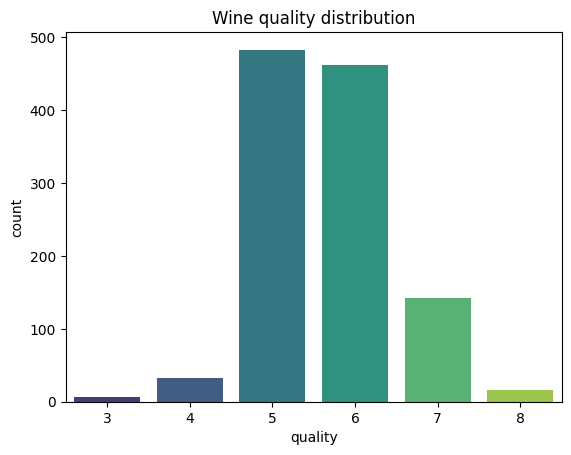

In [7]:
# Distribution of Target variable (Quality)

sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Wine quality distribution")
plt.show()

In [8]:
# Summary
print(df['quality'].value_counts().sort_index())

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [9]:
# Feature Distributions

df.drop("Id", axis=1, inplace=True)


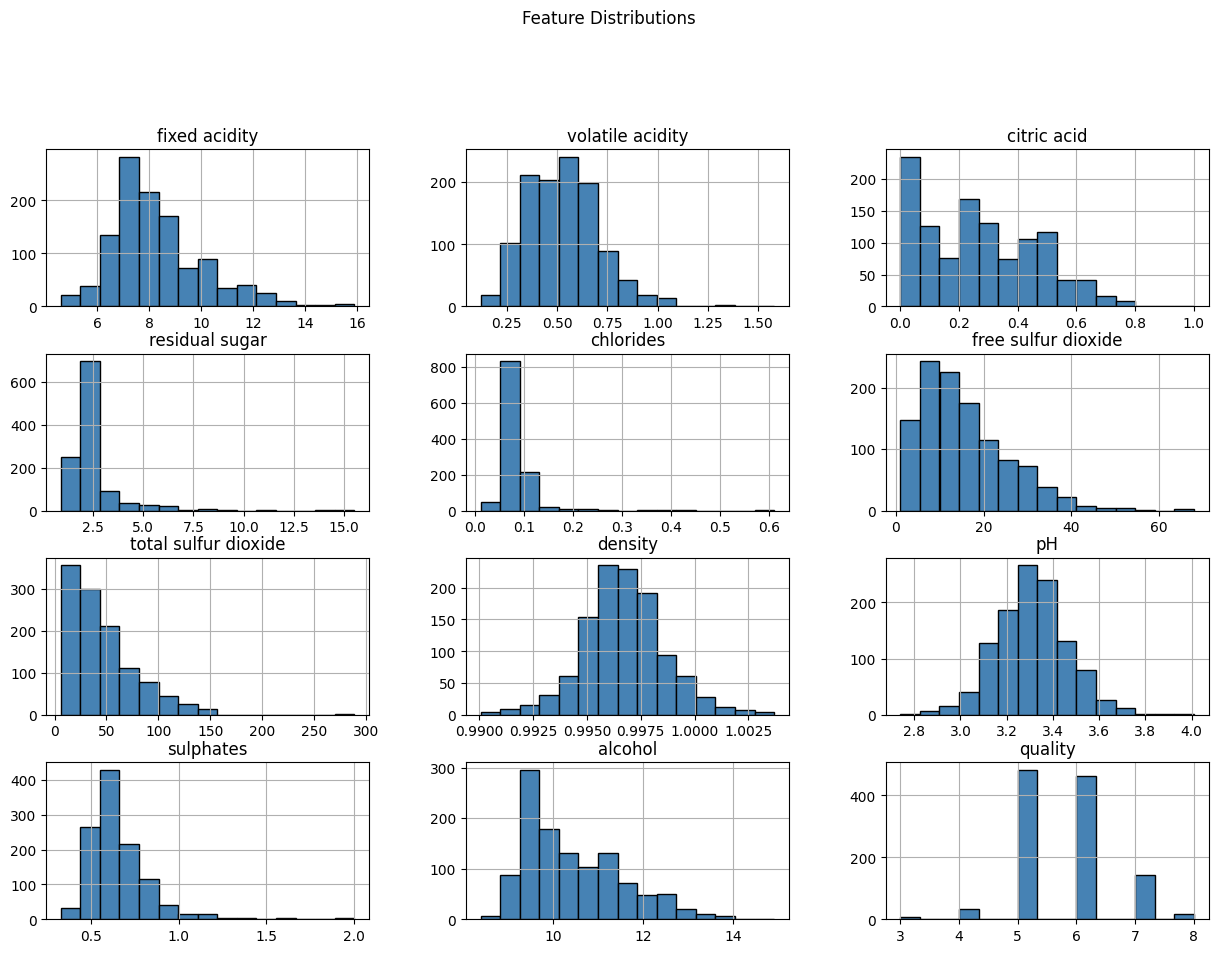

In [10]:
df.hist(bins=15, figsize=(15,10), color="steelblue", edgecolor="black")
plt.suptitle("Feature Distributions", y=1.02)
plt.show()

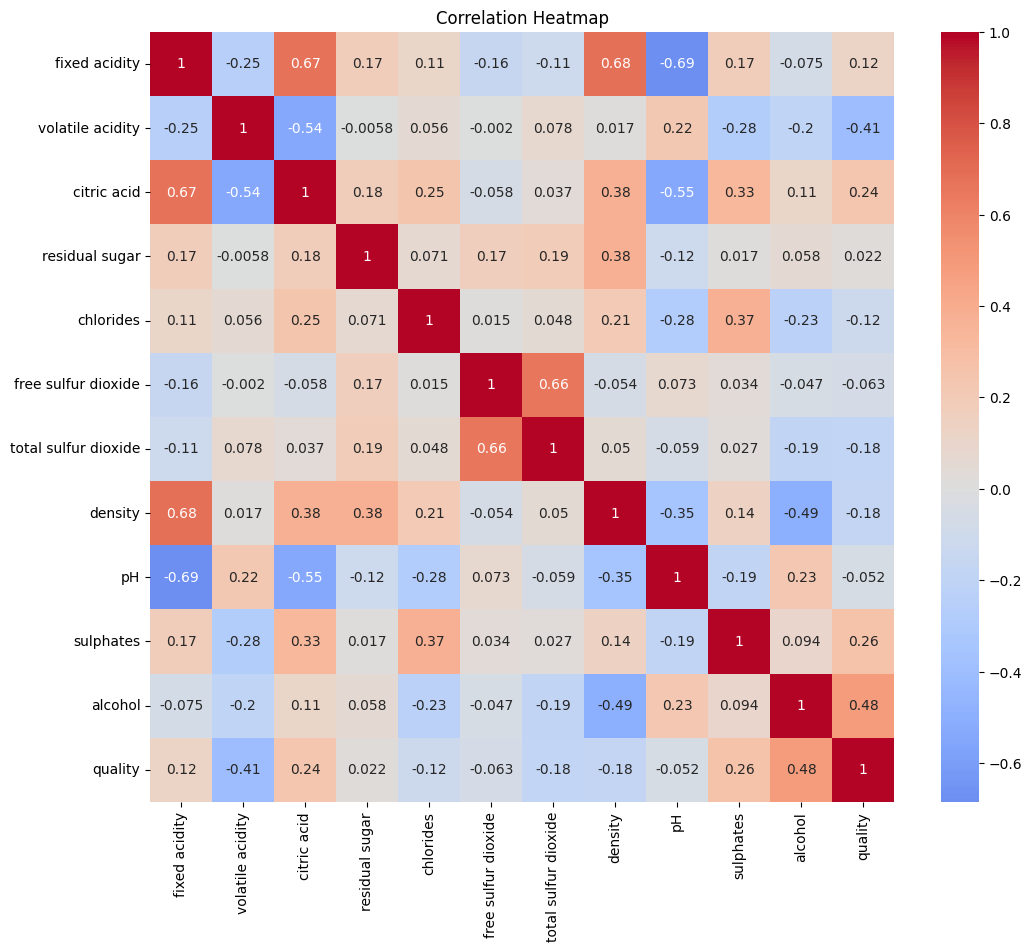

In [11]:
# Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

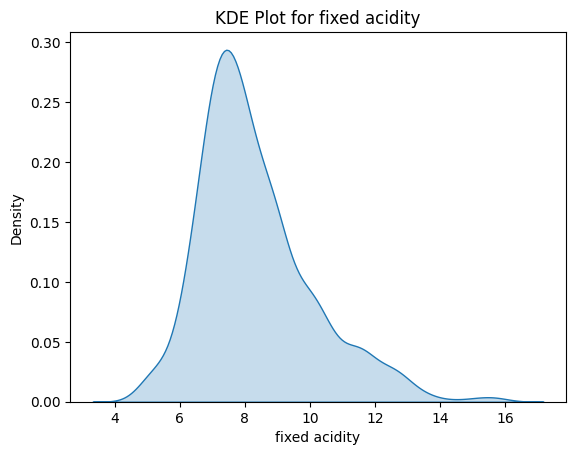

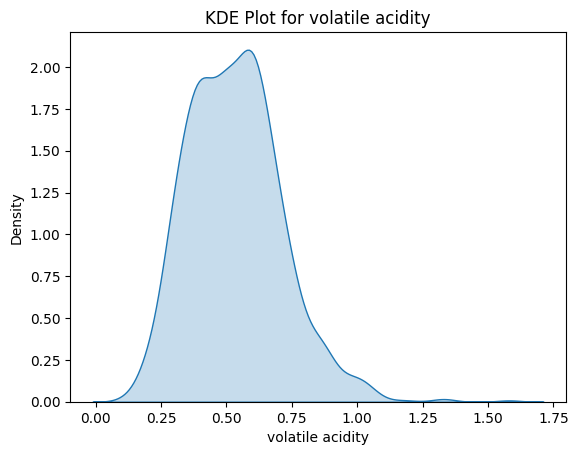

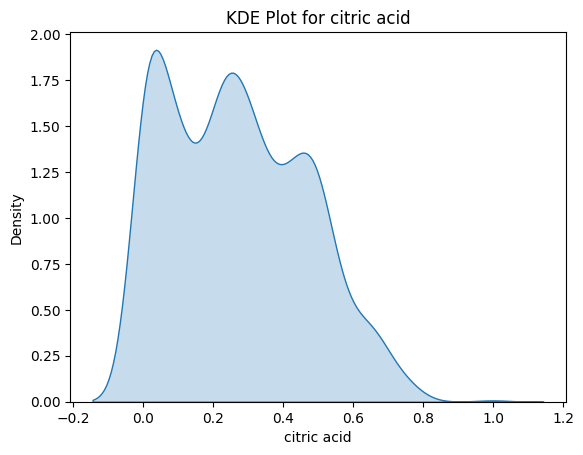

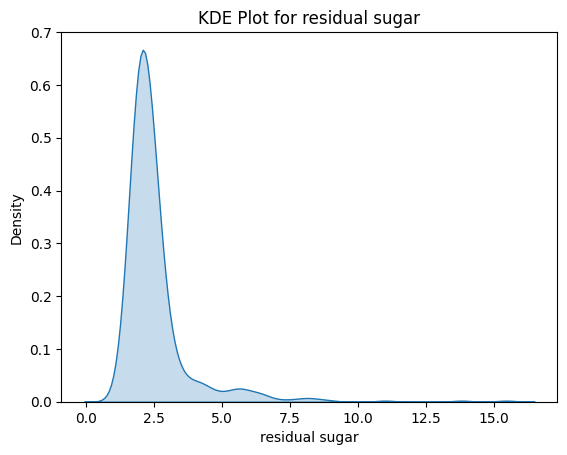

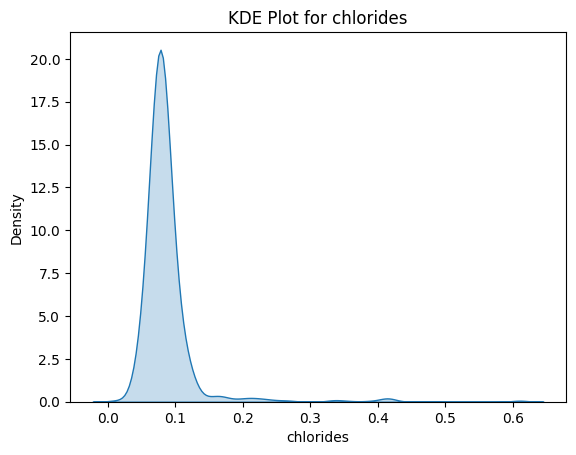

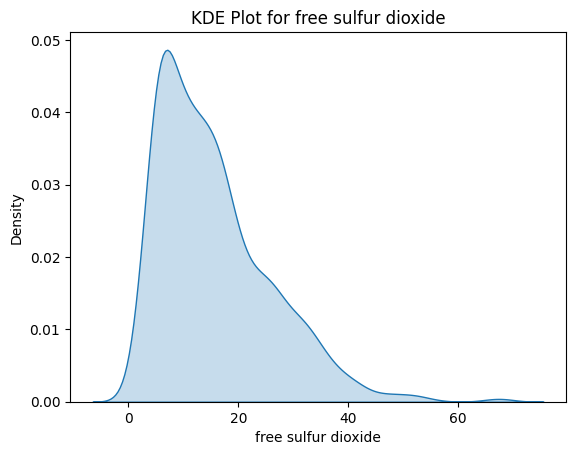

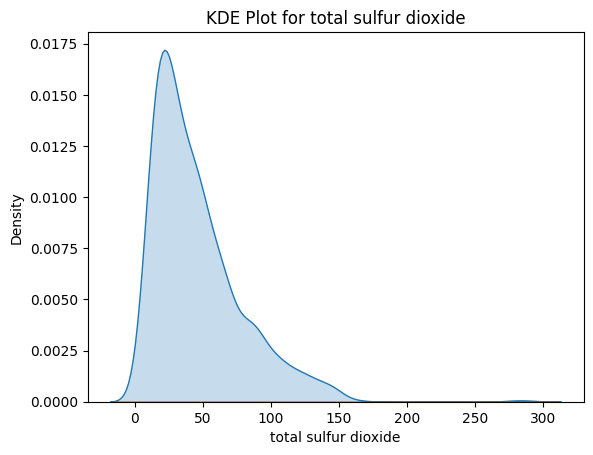

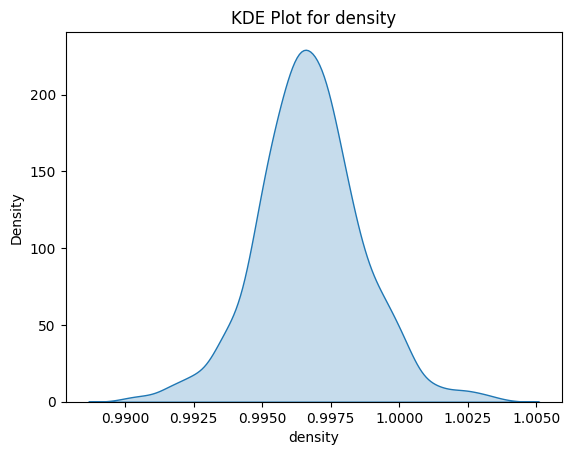

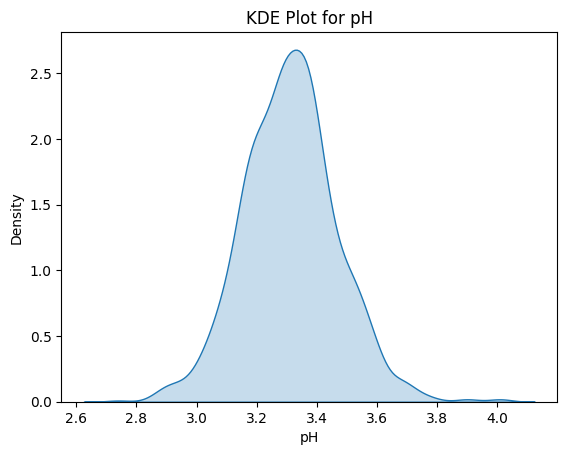

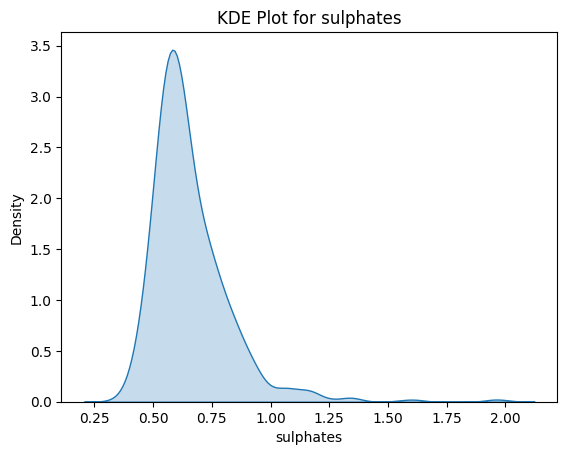

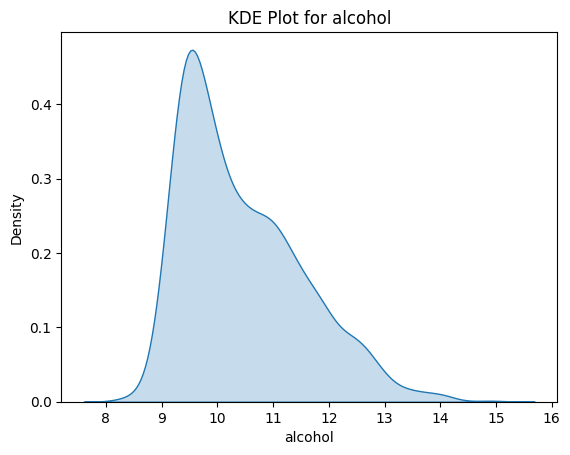

In [13]:
# KDE plots for smooth density
for col in df.drop(columns=['quality']).columns:
    sns.kdeplot(df[col], fill=True)
    plt.title(f'KDE Plot for {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

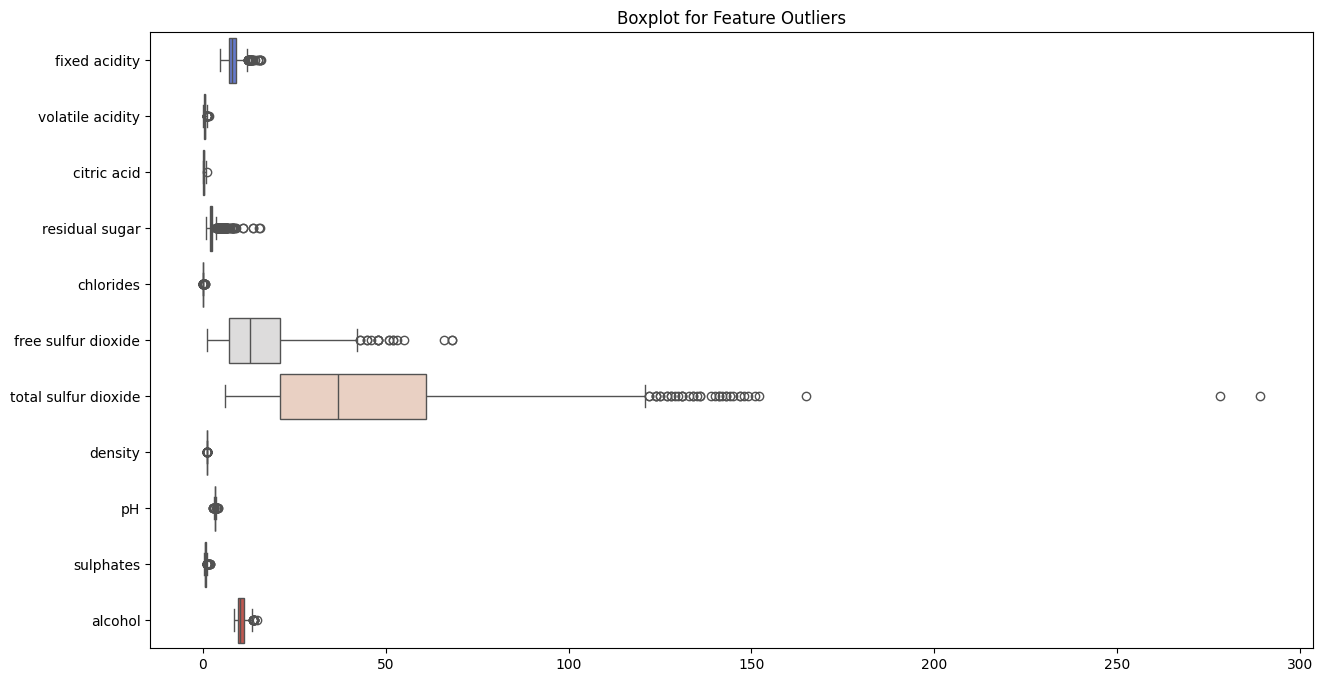

In [14]:
# Boxplot to check outliers
plt.figure(figsize=(15,8))
sns.boxplot(data=df.drop(columns=['quality']), orient='h', palette="coolwarm")
plt.title("Boxplot for Feature Outliers")
plt.show()

In [15]:
df.columns.to_list()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

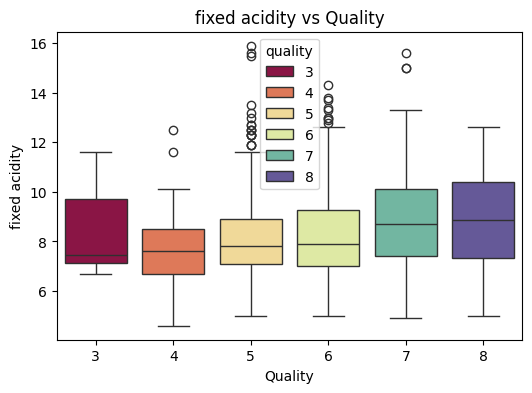

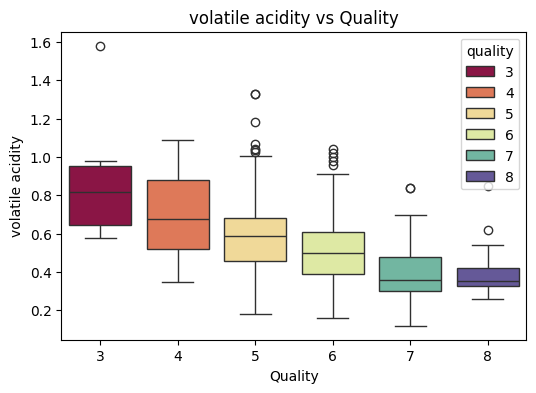

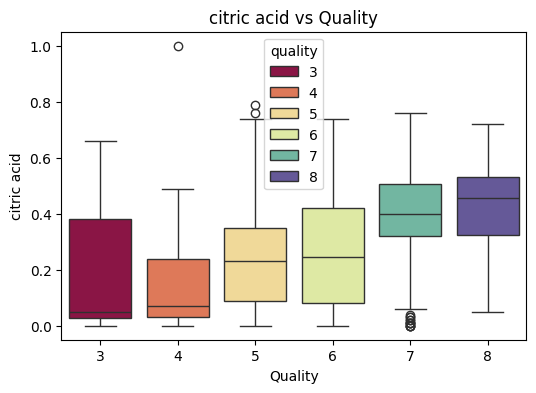

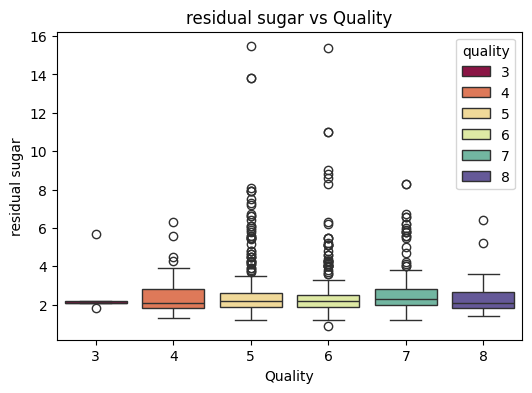

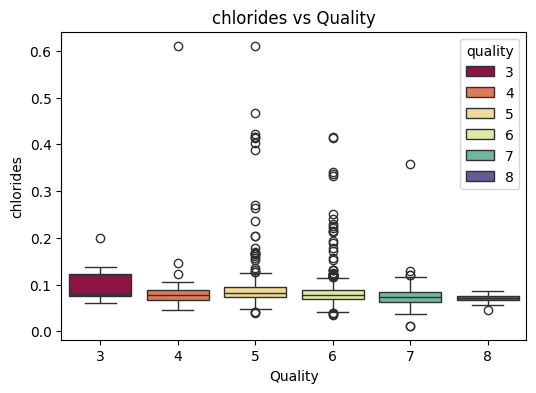

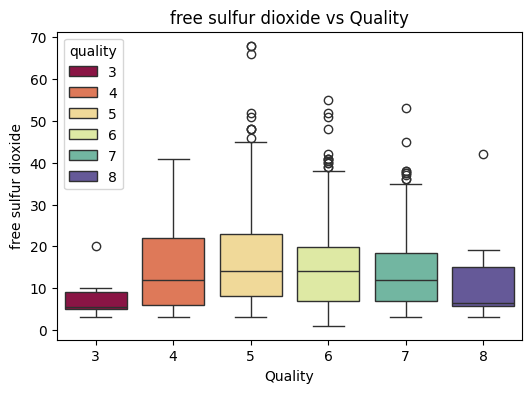

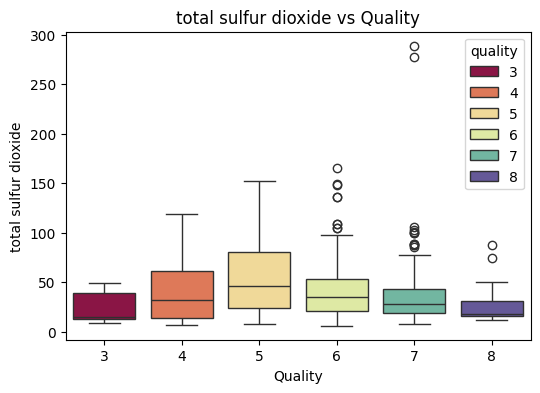

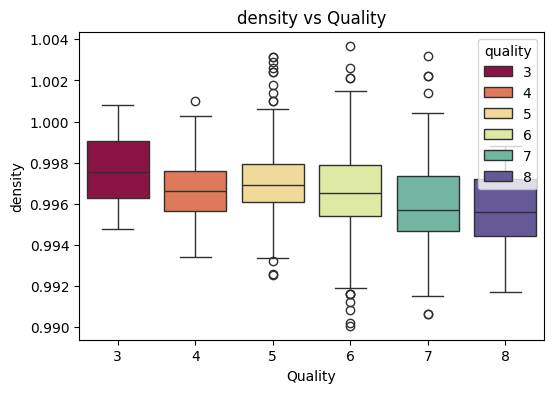

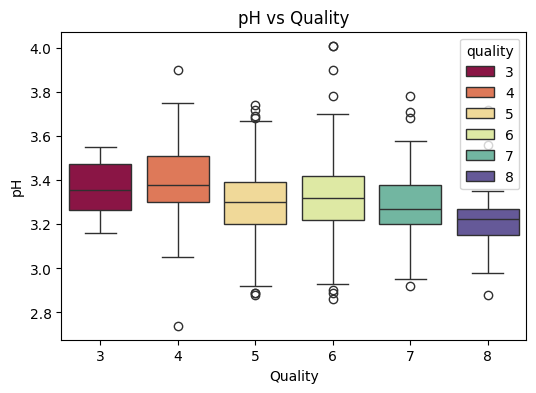

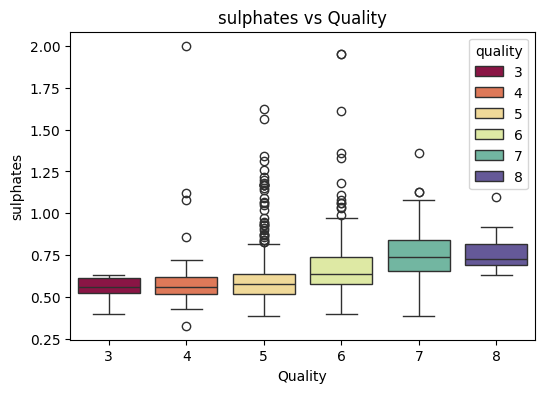

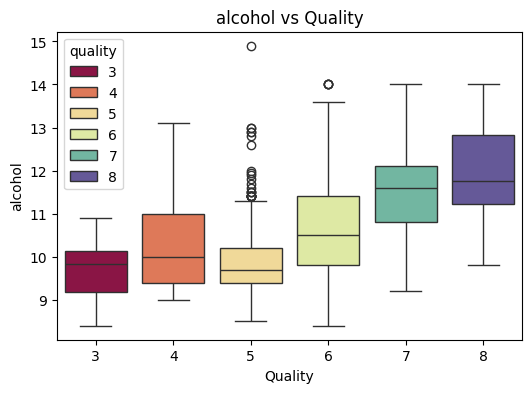

In [16]:
# Feature vs Target (Quality)
for col in df.drop(columns=['quality']).columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='quality', y=col, data=df, palette="Spectral", hue="quality")
    plt.title(f'{col} vs Quality')
    plt.xlabel('Quality')
    plt.ylabel(col)
    plt.show()


In [17]:
# Outliers Detection using IQR
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)  
iqr = q3 - q1
outliers = ((df < (q1 - 1.5 * iqr)) | (df > (q3 + 1.5 * iqr))).sum()
print("Number of outliers in each feature:\n", outliers)

Number of outliers in each feature:
 fixed acidity            44
volatile acidity         14
citric acid               1
residual sugar          110
chlorides                77
free sulfur dioxide      18
total sulfur dioxide     40
density                  36
pH                       20
sulphates                43
alcohol                  12
quality                  22
dtype: int64


In [18]:
# Optional cleaned dataset
df_cleaned = df[~((df < (q1 - 1.5 * iqr)) | (df > (q3 + 1.5 * iqr))).any(axis=1)]
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")

Original dataset shape: (1143, 12)
Cleaned dataset shape: (834, 12)


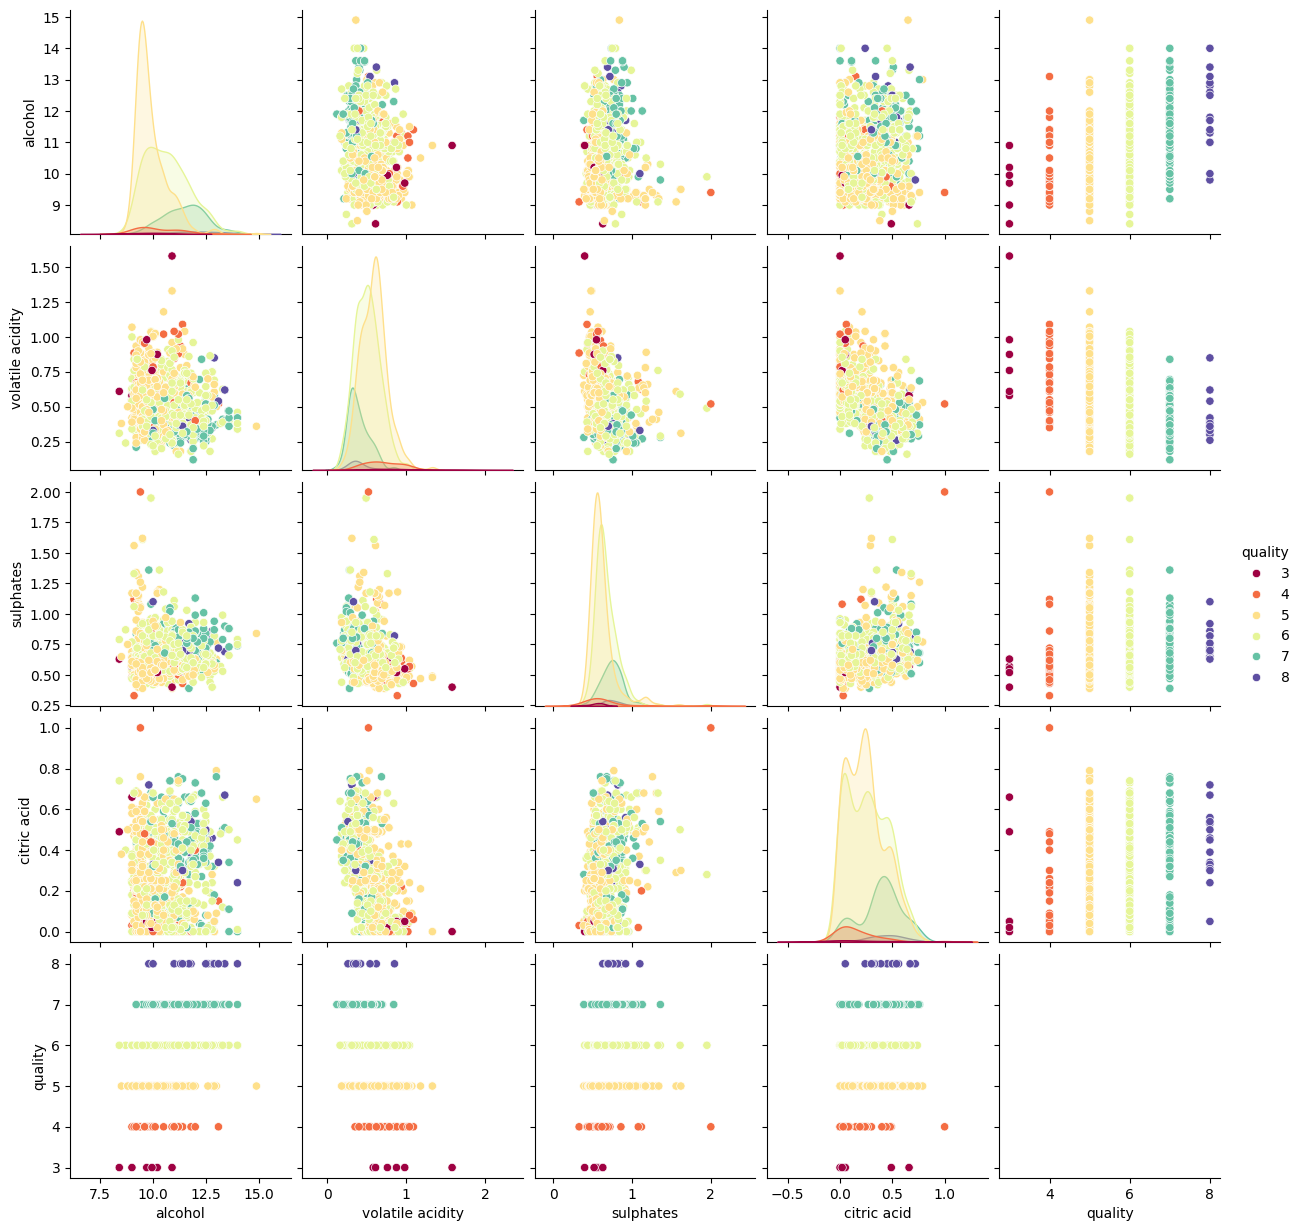

In [20]:
# Pairplot for selected features (intersecting relationships)
sns.pairplot(df, vars=['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'quality'], hue='quality', palette="Spectral", diag_kind='kde')


# Summary of EDA

- Quality distribution: Most wines are rated 5-7, very few extreme low/high

Key Correlations:
- Alcohol: Quality inc. (higher alcohol -> better wine)
- Volatile acidity inc. -> Quality dec. (more acidic -> worse wine)
- Citric acid, sulphates, density also show pattern
- Outliers: Present in residual sugar, suplhates, alcohol

Insight: Higher-quality wines tend to have higher alcohol, lower volatile acidity, higher citric acid & sulphates

## Inferential Analysis

In [22]:
import numpy as np
from scipy.stats import ttest_ind

In [23]:
# Define low-quality (<=5) and high-quality (>=7) groups
low_quality = df[df['quality'] <= 5]
high_quality = df[df['quality'] >= 7]

In [24]:
print("Low-quality group shape:", low_quality.shape)
print("High-quality group shape:", high_quality.shape)

Low-quality group shape: (522, 12)
High-quality group shape: (159, 12)


In [26]:
t_results = {}
for col in df.drop(columns=['quality']).columns:
    t_stat, p_val = ttest_ind(low_quality[col], high_quality[col], equal_var=False)
    t_results[col] = {"t_statistic": t_stat, "p_value_full": f"{p_val}", "p_value": f"{p_val:.6f}"}

In [28]:
t_results_df = pd.DataFrame(t_results).T.sort_values(by="p_value")
t_results_df

,t_statistic,p_value_full,p_value
volatile acidity,15.133247,5.191581012917868e-40,0.000000
citric acid,-8.951761,8.247749070836647e-17,0.000000
chlorides,5.174777,3.278432257491797e-07,0.000000
total sulfur dioxide,5.354912,1.8558924949851006e-07,0.000000
density,5.311745,2.751225747039604e-07,0.000000
sulphates,-9.755049,8.516456816493156e-20,0.000000
alcohol,-18.484496,1.5287300918242714e-46,0.000000
fixed acidity,-3.914228,0.00012177280943401829,0.000122
free sulfur dioxide,2.410791,0.016552129650869468,0.016552
pH,1.835919,0.0675102275044254,0.067510
